<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/YB_0515_exercises_%ED%9A%8C%EA%B7%802.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 규제 선형 회귀 모델/ 회귀 트리**
- 릿지 회귀모델 및 회귀 트리를 이용하여 전복의 나이를 예측해 보세요.

- 전복의 ‘성별’, ‘키’, ‘지름’, ‘높이’, ‘전체무게’, ‘몸통무게’, ‘내장무게’, ‘껍질무게’를 이용해 ‘껍질의 고리수’를 예측한 뒤, **예측된 ‘껍질의 고리수’에 1.5를 더하면 전복의 나이**가 됩니다.

In [31]:
# 기본 모듈 불러오기
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1) 데이터 불러오기 및 데이터 선택

In [33]:
# 데이터 로드
data = pd.read_csv("/content/drive/MyDrive/YB_data/abalone.csv")

# 성별 M은 Male, F는 Female, I는 Infant 이므로 따로 열 만들기
for label in "MFI":
    data[label] = data["Sex"] == label
data.drop('Sex', axis=1, inplace=True)

# X,y 데이터 선택
y = data.Rings.values
data.drop('Rings', axis=1, inplace=True)

X = data.values.astype(float)

## 2) train/test 분리
: 테스트 셋과 데이터 셋을 7:3 비율로 분리하세요.

In [34]:
# 필요한 모듈 불러오기
from sklearn.model_selection import train_test_split

In [35]:
# train과 test set 분리 (train:test = 7:3 비율로)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## 확인
print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)

X_train 크기: (2923, 10)
X_test 크기: (1254, 10)
y_train 크기: (2923,)
y_test 크기: (1254,)


## 3) 릿지 모델을 이용한 모델링
: 릿지 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

 3-1) 릿지모델 생성, 교차검증, 평가에 필요한 모듈을 불러오세요.

In [36]:
#필요한 모듈 불러오기
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

3-2) 릿지 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요. 릿지 모델 생성 시  alpha는 0.3으로 설정합니다. (교차 검증 하지 않습니다.)

In [37]:
#릿지모델 생성 및 훈련
ridge = Ridge(alpha=0.3)
ridge.fit(X_train, y_train)

#예측값 구하기
y_pred = ridge.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
predict_age = y_pred + 1.5

#MSE와 RMSE구하기
actual_age = y_test + 1.5

mse = mean_squared_error(actual_age, predict_age)
rmse = np.sqrt(mse) # numpy의 sqrt 함수로 루트를 씌움

3-3) 릿지 모델에서 회귀 계수 값을 구해 알 수 있는 점을 작성하시오. (각 컬럼의 정보는 data.colums 참고)

In [38]:
data.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'M', 'F', 'I'],
      dtype='object')

1) 변수의 중요도 (영향력 크기):

회귀 계수의 절댓값이 클수록 전복의 나이(껍질의 고리 수)를 예측하는 데 더 큰 영향을 미치는 중요한 특성(Feature)임을 알 수 있음


2) 상관관계의 방향:

- 계수가 양수(+)인 컬럼(ex. 전체무게, 껍질무게 등)은 해당 수치가 증가할수록 전복의 나이도 많아지는 경향이 있음을 의미함

- 계수가 음수(-)인 컬럼은 수치가 증가할수록 전복의 나이가 적게 예측됨을 의미함

3-3) 교차검증을 이용하여 0, 0.1, 1, 10, 100 중  모델 성능이 가장 좋게 나오는 (rmse가 최소가 되는) alpha를 구하세요.

In [39]:
# 주어진 alpha
alphas=[0, 0.1, 1, 10, 100]

In [40]:
#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha=alpha)

    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    # scoring='neg_mean_squared_error'를 통해 반환된 음수 MSE 값을 양수로 바꾸고 루트를 씌움
    neg_mse_scores = cross_val_score(ridge, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)

    print(f'alpha가 {alpha} 일 때 5 폴드 평균 RMSE: {avg_rmse:.4f}')

alpha가 0 일 때 5 폴드 평균 RMSE: 2.2420
alpha가 0.1 일 때 5 폴드 평균 RMSE: 2.2282
alpha가 1 일 때 5 폴드 평균 RMSE: 2.2152
alpha가 10 일 때 5 폴드 평균 RMSE: 2.3650
alpha가 100 일 때 5 폴드 평균 RMSE: 2.6364


## 4) XGBRegressor을 이용한 모델링
: XGBRegressor 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

4-1) XGBRegressor 훈련, 평가에 필요한 모듈을 불러오세요.

In [41]:
# 필요한 모듈 임포트
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

4-2) XGBregressor 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요.

In [42]:
#모델 생성 및 훈련
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

#예측값 구하기
y_pred_xgb = xgb.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
predict_age_xgb = y_pred_xgb + 1.5

#MSE와 RMSE 구하기
actual_age = y_test + 1.5  # 정확한 오차 계산을 위해 실제 나이를 먼저 정의

mse = mean_squared_error(actual_age, predict_age_xgb)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 5.5060
RMSE: 2.3465


4-3) 생성한 모델의 피처 중요도를 시각화해보세요.

<Axes: ylabel='None'>

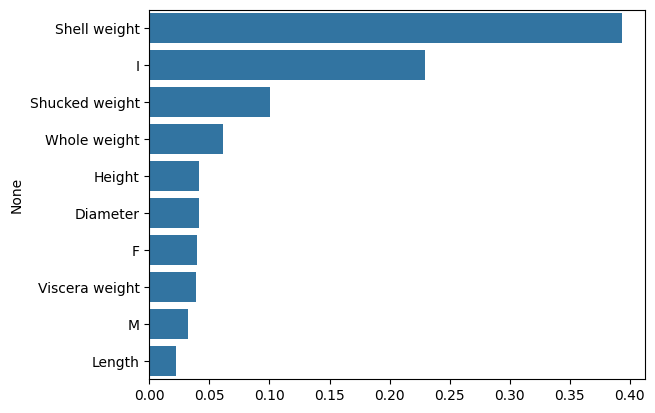

In [43]:
import seaborn as sns
%matplotlib inline

ft_importance = pd.Series(xgb.feature_importances_, index=data.columns).sort_values(ascending=False)
sns.barplot(x=ft_importance.values, y=ft_importance.index)

# **2. 로지스틱 회귀분석**
load_wine() 함수를 이용하여 와인 데이터를 다항분류하는 로지스틱 회귀모델을 생성하세요.

In [44]:
# 필요한 모듈 불러오기
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

## 1) 데이터 불러오기 및 변수 선택

In [45]:
wine = load_wine()

wine_x = wine.data # x변수
wine_y = wine.target # y변수

## 2) train/test 셋 분리

In [46]:
x_train, x_test, y_train, y_test = train_test_split(wine_x, wine_y, test_size=0.3, random_state=123)

x_train.shape
y_train.shape

(124,)

## 3) 로지스틱 회귀모델을 이용한 모델링

3-1) 로지스틱 회귀모델을 생성하여 훈련하세요.

In [47]:
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(x_train, y_train)
print("모델 훈련 완료")

모델 훈련 완료


3-2) 회귀 모델의 기울기와 절편을 구하세요.

In [48]:
#기울기
print(lr_model.coef_)

[[ 0.42439298  0.54744452  0.62026175 -0.25946906 -0.00207495  0.25257608
   0.75790461  0.09118418  0.14341218  0.1758945  -0.01150508  0.51869373
   0.00865839]
 [-0.61350726 -0.91046142 -0.69744893  0.14881052 -0.04174846  0.31231432
   0.15345516  0.03003637  0.39268846 -0.9168763   0.32597234  0.13224331
  -0.00767599]
 [ 0.18911428  0.3630169   0.07718717  0.11065854  0.0438234  -0.5648904
  -0.91135977 -0.12122055 -0.53610064  0.7409818  -0.31446726 -0.65093704
  -0.0009824 ]]


In [49]:
#절편
print(lr_model.intercept_)

[-13.57617163  21.30986693  -7.73369529]


3-3) 모델의 정확도를 구하세요.

In [50]:
#모델의 예측값 구하기
y_pred = lr_model.predict(x_test)

#모델의 정확도 구하기
accuracy = metrics.accuracy_score(y_test, y_pred)

print(f"모델 정확도: {accuracy:.4f}")

모델 정확도: 0.9630
